In [2]:
import pandas as pd

df = pd.read_csv("../data/student_performance.csv")
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [3]:
df.dtypes

student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                          str
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 45.8 MB


In [10]:
df["Pass"] = df["grade"].apply(
    lambda x: 0 if x == "F" else 1
)

df.sort_values(by="total_score", ascending=True).head(20)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,Pass
114309,114310,0.0,72.5,3.8,9.4,F,0
384794,384795,0.0,84.0,5.0,12.2,F,0
128034,128035,0.0,74.4,6.9,14.4,F,0
430442,430443,1.5,70.5,5.0,14.6,F,0
2118,2119,0.0,79.8,2.7,14.6,F,0
69236,69237,0.8,73.6,7.2,14.7,F,0
172145,172146,0.1,97.6,3.0,15.7,F,0
469884,469885,2.4,87.6,4.2,15.9,F,0
429373,429374,0.0,62.8,2.3,16.2,F,0
392503,392504,2.3,95.9,6.2,16.4,F,0


In [11]:
df.sort_values(by="total_score", ascending=False).head(20)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,Pass
3,4,25.7,70.2,7.0,100.0,A,1
2,3,19.5,86.3,5.3,100.0,A,1
466933,466934,19.0,90.6,3.9,100.0,A,1
466932,466933,19.9,85.9,8.8,100.0,A,1
466931,466932,23.0,95.1,7.7,100.0,A,1
466930,466931,28.6,76.8,8.3,100.0,A,1
466929,466930,17.5,92.4,4.8,100.0,A,1
466959,466960,16.4,87.2,10.0,100.0,A,1
466958,466959,34.0,74.0,5.9,100.0,A,1
466957,466958,19.3,84.7,3.0,100.0,A,1


In [5]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [12]:
df.shape

(1000000, 7)

In [13]:
#Outliers
#IQR

Q1 = df["total_score"].quantile(0.25)
Q3 = df["total_score"].quantile(0.75)

IQR = Q3 - Q1

lowest_point = Q1 - 1.5*IQR
highest_point = Q3 + 1.5*IQR

outlier = df[(df["total_score"] < lowest_point) | (df["total_score"] > highest_point)]
outlier.shape

(2027, 7)

In [14]:
outlier_removed = df[(df["total_score"] >= lowest_point) & (df["total_score"] <= highest_point)]

outlier_removed.shape

(997973, 7)

In [ ]:
df = outlier_removed.copy()

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


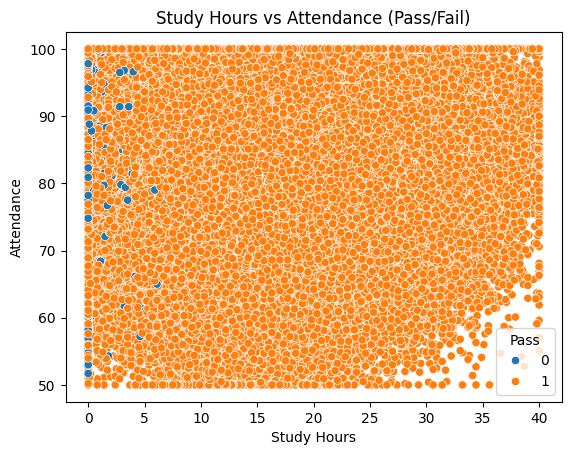

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(
    data=df,
    x="weekly_self_study_hours",
    y="attendance_percentage",
    hue="Pass"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Study Hours vs Attendance (Pass/Fail)")
plt.show()

In [24]:
df.corr(numeric_only = True)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,Pass
student_id,1.000000,-0.001607,-0.000353,0.001277,-0.000492,0.001072
weekly_self_study_hours,-0.001607,1.000000,-0.001008,0.001244,0.812241,0.154651
attendance_percentage,-0.000353,-0.001008,1.000000,-0.000043,-0.001014,-0.002202
class_participation,0.001277,0.001244,-0.000043,1.000000,0.000684,0.000277
total_score,-0.000492,0.812241,-0.001014,0.000684,1.000000,0.249887
Pass,0.001072,0.154651,-0.002202,0.000277,0.249887,1.000000


In [26]:
df.corr(numeric_only=True)["total_score"].sort_values(ascending=False)

total_score                1.000000
weekly_self_study_hours    0.812241
Pass                       0.249887
class_participation        0.000684
student_id                -0.000492
attendance_percentage     -0.001014
Name: total_score, dtype: float64

In [27]:
df.corr(numeric_only=True)["Pass"].sort_values(ascending=False)

Pass                       1.000000
total_score                0.249887
weekly_self_study_hours    0.154651
student_id                 0.001072
class_participation        0.000277
attendance_percentage     -0.002202
Name: Pass, dtype: float64

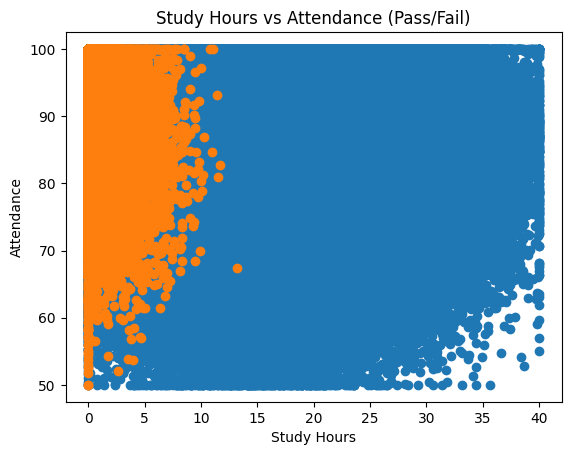

In [18]:
import matplotlib.pyplot as plt

plt.figure()

passed = df[df["Pass"] == 1]
failed = df[df["Pass"] == 0]

plt.scatter(passed["weekly_self_study_hours"], passed["attendance_percentage"])
plt.scatter(failed["weekly_self_study_hours"], failed["attendance_percentage"])

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Study Hours vs Attendance (Pass/Fail)")

plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df[["weekly_self_study_hours", "attendance_percentage"]]   # Features
y = df["Pass"]                         # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.993755
Confusion Matrix:
 [[     0   1249]
 [     0 198751]]


In [23]:
print(model.coef_)
print(model.intercept_)

[[ 4.03044759 -0.0210949 ]]
[10.34099938]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.993755


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[     0   1249]
 [     0 198751]]


### Key Predictors of Student Performance

#### 1. Study Hours

Strong positive relationship with passing
Students who study more hours per week are significantly more likely to pass
Logistic regression coefficient (if positive) confirms this

Interpretation:
Increasing study hours increases the probability of passing

#### 2. Attendance

Also a strong predictor
Higher attendance → better understanding → higher pass rate
Often slightly more consistent than study hours

Interpretation:
Students attending more classes are more likely to pass

#### 3. Relative Importance (from model coefficients)

Check:
print(model.coef_)
Larger coefficient = stronger influence

Example:
Attendance > StudyHours → attendance matters more
StudyHours > Attendance → self-study matters more
This is your actual data-driven insight, not guesswork.

#### 4. Combined Effect (the real story)

Neither feature works alone perfectly:
Low study + low attendance → almost guaranteed fail
High study + high attendance → very high pass probability
Mixed cases → model uncertainty

Insight:
Student performance is best explained by a combination of consistent attendance and sufficient study time

#### 5. ⚠️ Model Behavior Insight

Logistic regression assumes a linear relationship in log-odds

So:

Gains from increasing study hours may plateau

Same for attendance near 100%